<a href="https://colab.research.google.com/github/RaziehSh1987/Python_Data-Analysis/blob/main/Python(Data_analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Read from files

In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv("/content/data.csv", encoding='cp1252')

#Read from Excel
# pd.read_excel("/content/sample_data/data.xlsx",sheet_name="Sheet_name")

#Read and write from json
# import json
# with open("file.json", 'r',encoding='utf-8') as f:
#   cfg=json.load(f)
# cfg["threshold_mm"]=2.0

# with open("file.json", 'w',encoding='utf-8') as f:
#   json.dump(cfg,f,indent=2)


/tmp/ipykernel_550/3738351033.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/data.csv", encoding='cp1252')


In [ ]:
df.info() # show dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [ ]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


#replace Non value (missing value) with 0

In [4]:
df=df.fillna(0)


#Detect missing columns

In [5]:

require_col={'stn_code','location','type','so2','no2'}
missing=require_col- set(df.columns)
if missing:
  raise ValueError(f'Missing columns: {missing}')
print(df.dtypes)

stn_code                        object
sampling_date                   object
state                           object
location                        object
agency                          object
type                            object
so2                            float64
no2                            float64
rspm                           float64
spm                            float64
location_monitoring_station     object
pm2_5                          float64
date                            object
dtype: object


#Example: must be non-negative

In [6]:
neg_so2=df['so2']<0
if neg_so2.any():
  bad_rows=df.loc[neg_so2,['stn_code','location','type','so2','no2']]
  raise ValueError(f'negative value found in :\n {bad_rows}')


#Missing value check

In [ ]:
if df['stn_code'].isna().any():
  n=df['stn_code'].isna().sum()
  raise ValueError(f'stn_code has {n} missing values')


#Standardize
- Case 1 — regex=False (literal text)
df["sampling_date"].str.replace(" - M", " ", regex=False)
  - Meaning:  Replace the exact text " - M" with " ".
  - Example:  "February - M021990" => "February 021990"
- Case 2 — regex=True (pattern matching)

  - Example: df["sampling_date"].str.replace(r"M\d+", "", regex=True)

  - Pattern: M\d+  means => letter M followed by digits

  - Example transformation: February - M021990 becomes => February -

- Meaning of errors='coerce' It means:  If a value cannot be converted, replace it with NaN (or NaT for datetime) instead of raising an error.


In [70]:
df['sampling_date']=df['sampling_date'].astype(str) # cast to string
df['sampling_date']=(df['sampling_date'].str.replace(' - M'," ",regex=False)) # remove unclear data like - M
print(df['sampling_date'])

0         February 021990
1         February 021990
2         February 021990
3            March 031990
4            March 031990
               ...       
435737           24-12-15
435738           29-12-15
435739                nan
435740                nan
435741                nan
Name: sampling_date, Length: 435742, dtype: object


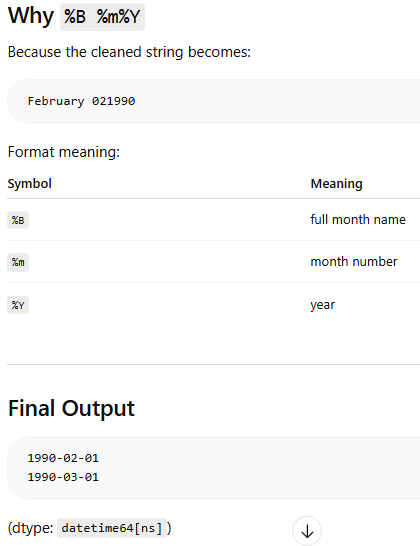

In [71]:
df['sampling_date_1']=pd.to_datetime(df['sampling_date'],format='%B %m%Y',errors='coerce') #%B= full month name February() %y=year
print(df['sampling_date_1'])

0        1990-02-01
1        1990-02-01
2        1990-02-01
3        1990-03-01
4        1990-03-01
            ...    
435737          NaT
435738          NaT
435739          NaT
435740          NaT
435741          NaT
Name: sampling_date_1, Length: 435742, dtype: datetime64[ns]


In [33]:
print(np.count_nonzero(df)) #befor removing duplicate

dup=df.duplicated(set(df.columns),keep=False)
print(dup.sum()) # number of duplicate data

dup_df=df.drop_duplicates(set(df.columns),keep="last")
print(np.count_nonzero(dup_df))# after removing doplicate data


6096749
1348
6087324


   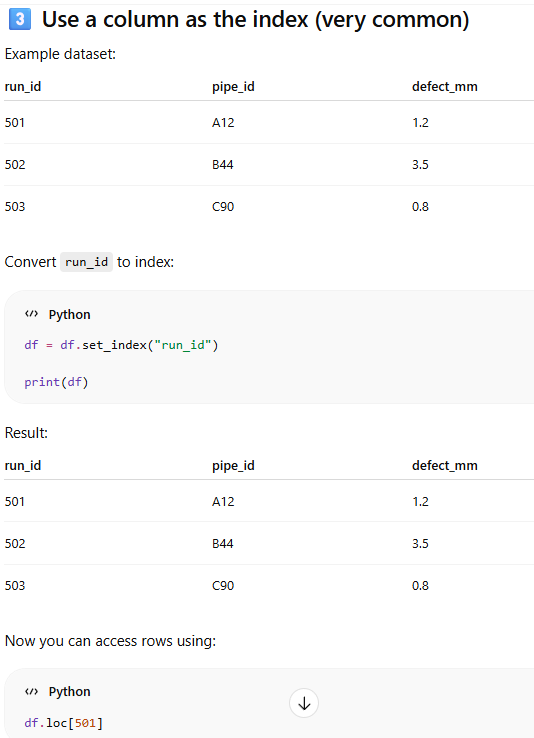

In [52]:
# df = df.set_index("run_id") # set a unique column as a index column
print(df[df['so2']>3.5].head(4))
print(df.loc[2,["stn_code","state"]])
# print(df)

  stn_code    sampling_date           state   location agency  \
0    150.0  February 021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February 021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March 031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March 031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date sampling_date_1  
0                         NaN    NaN  1990-02-01      1990-02-01  
2                         NaN    NaN  1990-02-01      1990-02-01  
3                         NaN    NaN  1990-03-01      1990-03-01  
4                         NaN    NaN  1990-03-01      1990-03-01  
stn_code             15

In [36]:
dff = pd.DataFrame({"a":[10,20,30], "b":[1,2,3]}, index=[100,101,102])
print(dff)

      a  b
100  10  1
101  20  2
102  30  3


In [39]:
print(dff.loc[102])
print(dff.iloc[1])

a    30
b     3
Name: 102, dtype: int64
a    20
b     2
Name: 101, dtype: int64


In [42]:
print(dff[dff['b']>2])

      a  b
102  30  3


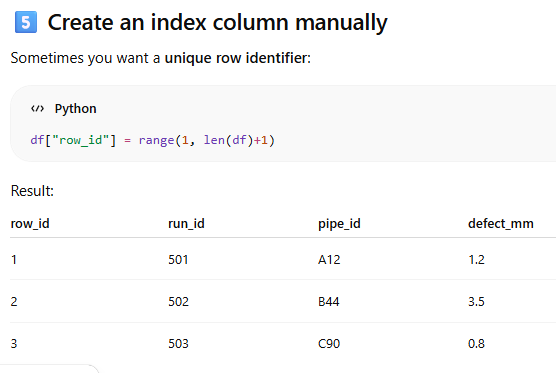

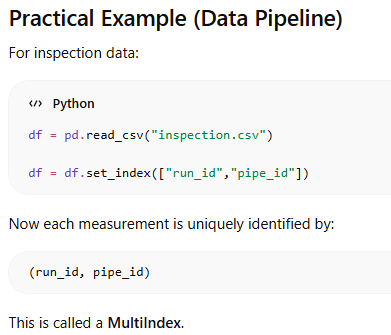

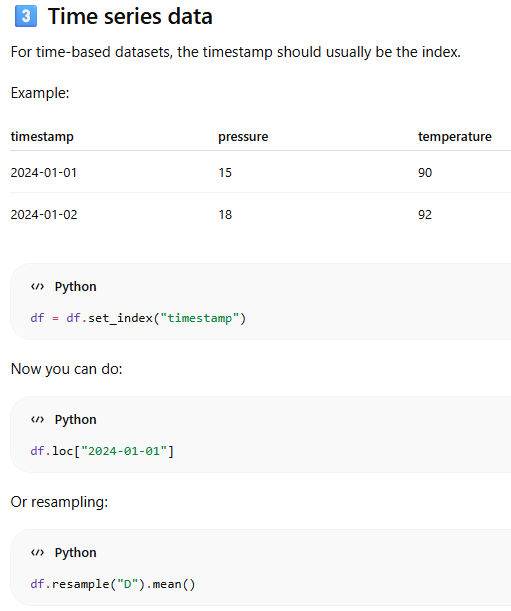

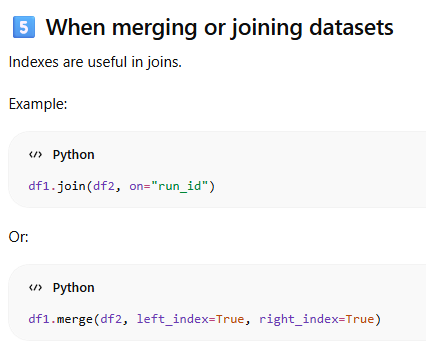

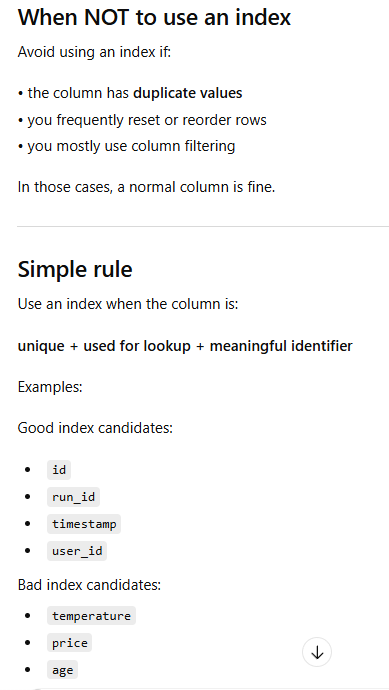

In [59]:
print(len(dff))
dff["row_index"]=range(1,len(dff)+1)
print(dff)

3
      a  b  row_index
100  10  1          1
101  20  2          2
102  30  3          3


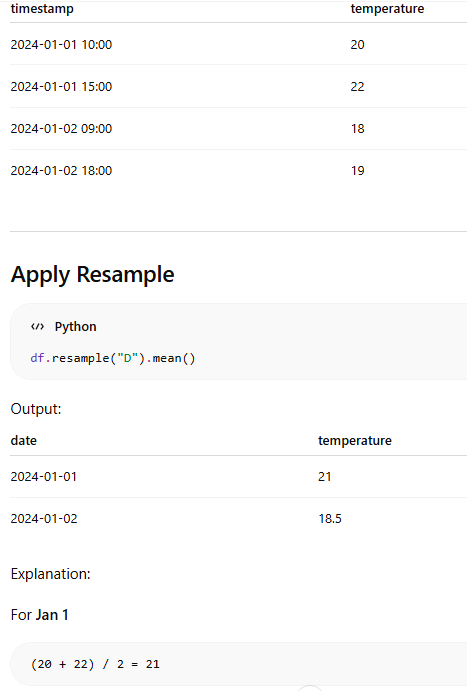

# resample("D") means:

Group the data by Day  Then .mean() means:

Compute the average value for each day

In [ ]:
df=df.set_index('sampling_date_1')
df.resample("D").mean()

# groupby("pipe_id")
- df.groupby("pipe_id")
- It groups rows that belong to the same pipe.
    - Group A12
   1.2
   2.0
    - Group B44
   3.5
   2.9
 - .agg() (Aggregation) -> This calculates summary statistics for each group.
 - avg_defect=("defect_mm", "mean") -> Average defect size per pipe
 - max_defect=("defect_mm", "max") -> Maximum defect size in that pipe
 - n=("defect_mm", "size") -> Count how many inspections exist
- .reset_index() -> After groupby, pipe_id becomes the index.  This line converts it back into a normal column.



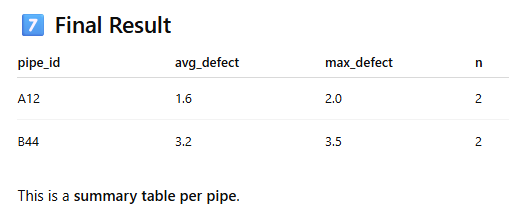

##  Then store as a CSV file:

In [5]:
kpi=(df.groupby('location').agg(avg=('so2','mean'),
                                max=('so2',"max"),
                                number=('so2','size')).reset_index())
print(kpi)
kpi.to_csv("location.csv", index=False)

           location        avg    max  number
0        ANKLESHWAR  18.940120   26.0     167
1              Agra   6.168916   49.0    7306
2         Ahmedabad  14.184336  166.3    6256
3            Aizawl   2.090873    8.0    3499
4             Akola   7.937023   13.0    1048
..              ...        ...    ...     ...
299        Warangal   5.484000   39.0     630
300         Wayanad   2.006445    5.3     512
301  West Singhbhum  20.947020   40.0     151
302    Yamuna Nagar  20.518885   47.0     329
303     Yamunanagar  14.880303   40.8     220

[304 rows x 4 columns]


## store in a Database:

In [ ]:
import  psycopg2
conn=psycopg2.connect(
    host='localhost',
    database='inspection_db',
    user='user',
    password='password'
)

kpi.to_sql("new_database_name",conn,if_exists='replace')

## Merge it with the original dataset:

In [ ]:
df=df.merge(kpi,on='location',how='left')
print(df)

## Logging

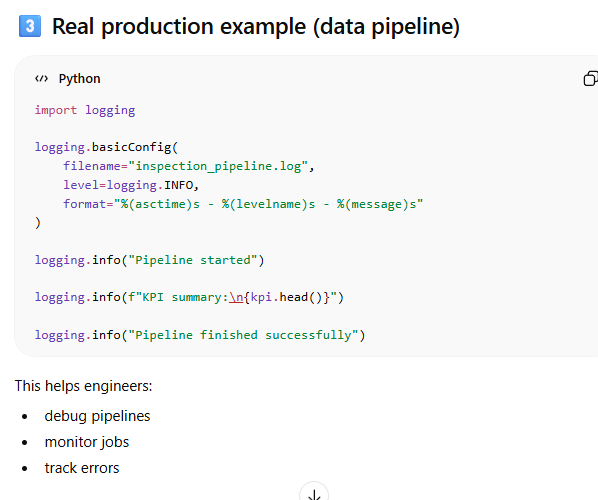

In [10]:
import logging
logging.basicConfig(filename='appLog.log',level=logging.INFO,format='%(asctime)s:%(levelname)s:%(message)s')
logging.info(f"avg detect per location {kpi.head(5)}")

## Pivot:

In [ ]:
pivot_table=df.pivot(index="column_name" , columns="column_name", values="column_name_numbers")

# Apply:
- .apply() runs a Python function on every row or value.
- .apply() is slow because:

    - It runs pure Python loops

    - Pandas cannot optimize it

    - It does row-by-row processing

    - If you have 1 million rows, .apply() may take seconds.

In [21]:
def bucket(mm:float) -> str:
  if mm<1:
    return "low"
  elif mm<3:
    return "mid"
  return "high"

df['severity']=df['so2'].apply(bucket)
print(df.head(4)[['severity','so2','location']])

  severity  so2   location
0     high  4.8  Hyderabad
1     high  3.1  Hyderabad
2     high  6.2  Hyderabad
3     high  6.3  Hyderabad


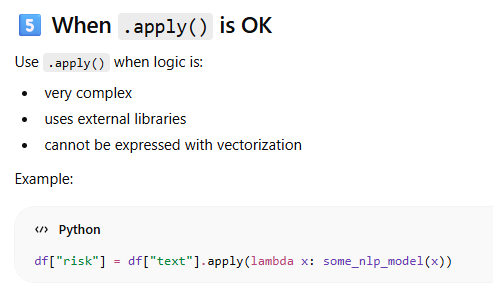

# Vectorized operations (recommended)

- Vectorized operations use NumPy internally, which runs in compiled C code, so it's much faster.


In [25]:
df['severity_2']=np.select([df['so2']<1 , df['so2']<3],['low','mid'],default='high')
print(df.head(4)[['severity_2','so2','location']])

  severity_2  so2   location
0       high  4.8  Hyderabad
1       high  3.1  Hyderabad
2       high  6.2  Hyderabad
3       high  6.3  Hyderabad


- Another vectorized option (very common)

    - Using np.where():

In [26]:
df['severity_3']= np.where(df['so2']<1,'low',np.where(df['so2']<3,'mid','high'))
print(df.head(4)[['severity_3','so2','location']])

  severity_3  so2   location
0       high  4.8  Hyderabad
1       high  3.1  Hyderabad
2       high  6.2  Hyderabad
3       high  6.3  Hyderabad
